# 01 - EDA e construção do Data Mart inicial (Passos Mágicos / PEDE)

Este notebook tem como objetivos:

1. Carregar as bases de dados fornecidas para o Datathon (PEDE / Passos Mágicos).
2. Fazer uma Análise Exploratória Inicial (EDA) para entender estrutura, tipos e qualidade dos dados.
3. Montar um **Data Mart analítico** em formato "Aluno x Ano", que será utilizado:
   - nos notebooks de modelagem preditiva;
   - na construção dos dashboards analíticos;
   - e na aplicação em Streamlit.


- **RA**: Identificador único do aluno na base do Datathon 2024. Campo técnico, utilizado apenas para controle e junções entre tabelas. Não possui interpretação direta de negócio.



In [ ]:
# 01 - Imports básicos e configurações

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)

sns.set(style="whitegrid")



In [ ]:
# 02 - Carregando base principal (Datathon 2024)

ARQ = "/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

# Mapeie as abas que existem no seu arquivo
abas = {
    "PEDE2022": 2022,
    "PEDE2023": 2023,
    "PEDE2024": 2024,
}

def padroniza_colunas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Padroniza colunas:
    - remove espaços
    - uppercase
    - troca espaços por underscore
    - remove acentos comuns
    """
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_", regex=False)
        .str.replace("Ç", "C", regex=False)
        .str.replace("Á", "A", regex=False)
        .str.replace("À", "A", regex=False)
        .str.replace("Ã", "A", regex=False)
        .str.replace("Â", "A", regex=False)
        .str.replace("É", "E", regex=False)
        .str.replace("Ê", "E", regex=False)
        .str.replace("Í", "I", regex=False)
        .str.replace("Ó", "O", regex=False)
        .str.replace("Õ", "O", regex=False)
        .str.replace("Ô", "O", regex=False)
        .str.replace("Ú", "U", regex=False)
    )
    return df

dfs = []
for aba, ano in abas.items():
    tmp = pd.read_excel(ARQ, sheet_name=aba)
    tmp = padroniza_colunas(tmp)
    tmp["ANO"] = ano
    tmp["FONTE_ABA"] = aba  # útil para debug (opcional)
    dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True)

df_all.shape, df_all.head(3)



((3030, 64),
      RA FASE TURMA     NOME  ANO_NASC  IDADE_22  GENERO  ANO_INGRESSO INSTITUICAO_DE_ENSINO  PEDRA_20  PEDRA_21  PEDRA_22  INDE_22     CG    CF    CT  Nº_AV   AVALIADOR1                REC_AV1  \
 0  RA-1    7     A  Aluno-1    2003.0      19.0  Menina          2016        Escola Pública  Ametista  Ametista   Quartzo    5.783  753.0  18.0  10.0    4.0  Avaliador-5  Mantido na Fase atual   
 1  RA-2    7     A  Aluno-2    2005.0      17.0  Menina          2017          Rede Decisão  Ametista  Ametista  Ametista    7.055  469.0   8.0   3.0    4.0  Avaliador-5      Promovido de Fase   
 2  RA-3    7     A  Aluno-3    2005.0      17.0  Menina          2016          Rede Decisão  Ametista  Ametista     Ágata    6.591  629.0  13.0   6.0    4.0  Avaliador-5      Promovido de Fase   
 
      AVALIADOR2                    REC_AV2    AVALIADOR3                    REC_AV3    AVALIADOR4                    REC_AV4  IAA  IEG  IPS    REC_PSICOLOGIA  IDA  MATEM  PORTUG  INGLES INDICADO  

In [ ]:
# 03 — Identificador do aluno (ID) e checagens básicas
# No seu caso, o identificador é RA (não existe um ID_ALUNO explícito)
ID_COL = "RA"

# Checagem básica
cols_check = [c for c in [ID_COL, "NOME", "TURMA", "FASE", "ANO"] if c in df_all.columns]
print("Colunas principais encontradas:", cols_check)

print("Linhas:", len(df_all))
print("Alunos únicos (RA):", df_all[ID_COL].nunique())
print("Anos:", sorted(df_all["ANO"].unique()))


Colunas principais encontradas: ['RA', 'NOME', 'TURMA', 'FASE', 'ANO']
Linhas: 3030
Alunos únicos (RA): 1661
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# 04 — Normalizar o INDE (nomes diferentes por ano)
def cria_coluna_inde(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Possíveis nomes existentes no arquivo
    candidatos = [c for c in ["INDE_22", "INDE_2022", "INDE_23", "INDE_2023", "INDE_24", "INDE_2024", "INDE"] if c in df.columns]

    if candidatos:
        # pega o primeiro não-nulo na ordem dos candidatos
        df["INDE"] = df[candidatos].bfill(axis=1).iloc[:, 0]
    else:
        df["INDE"] = np.nan

    df["INDE"] = pd.to_numeric(df["INDE"], errors="coerce")
    return df

df_all = cria_coluna_inde(df_all)

df_all[["ANO", "INDE"]].describe(include="all")


/tmp/ipython-input-3373131602.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["INDE"] = df[candidatos].bfill(axis=1).iloc[:, 0]


,ANO,INDE
count,3030.00000,2905.000000
mean,2023.09769,7.290767
std,0.80995,0.947098
min,2022.00000,3.031806
25%,2022.00000,6.741244
50%,2023.00000,7.410625
75%,2024.00000,7.953500
max,2024.00000,9.464745


In [ ]:
# 05 — Garantir que indicadores numéricos estão como número
indicadores_num = ["IAN", "IAA", "IEG", "IPS", "IDA", "IPP", "IPV", "INDE"]

for c in indicadores_num:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# % nulos por indicador numérico
pct_nulos = df_all[indicadores_num].isna().mean().sort_values(ascending=False)
pct_nulos


,0
IPP,0.342574
IDA,0.058746
IPV,0.058746
IPS,0.056436
IAA,0.054455
INDE,0.041254
IEG,0.025083
IAN,0.000000


In [ ]:
# 06 — Garantir que indicadores numéricos estão como número
# volume por ano
vol_ano = df_all.groupby("ANO").size().rename("qtd_linhas")
display(vol_ano)

# % nulos por indicador, por ano
nulos_ano = (
    df_all.groupby("ANO")[indicadores_num]
    .apply(lambda g: g.isna().mean())
)

nulos_ano


,qtd_linhas
ANO,
2022,860
2023,1014
2024,1156


,IAN,IAA,IEG,IPS,IDA,IPP,IPV,INDE
ANO,,,,,,,,
2022,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
2023,0.0,0.062130,0.074951,0.068047,0.075937,0.074951,0.074951,0.052268
2024,0.0,0.088235,0.000000,0.088235,0.087370,0.088235,0.088235,0.062284


In [ ]:
# 07 — Criar “Data Mart Analítico” em formato LONG
dim_cols = [c for c in [ID_COL, "ANO", "NOME", "GENERO", "FASE", "TURMA", "INSTITUICAO_DE_ENSINO"] if c in df_all.columns]
val_cols = [c for c in ["INDE", "IAN", "IAA", "IEG", "IPS", "IDA", "IPP", "IPV"] if c in df_all.columns]

df_long = df_all[dim_cols + val_cols].melt(
    id_vars=dim_cols,
    value_vars=val_cols,
    var_name="INDICADOR",
    value_name="VALOR_NUM"
)

df_long.shape, df_long.head(10)


((24240, 9),
       RA   ANO      NOME  GENERO FASE TURMA INSTITUICAO_DE_ENSINO INDICADOR  VALOR_NUM
 0   RA-1  2022   Aluno-1  Menina    7     A        Escola Pública      INDE      5.783
 1   RA-2  2022   Aluno-2  Menina    7     A          Rede Decisão      INDE      7.055
 2   RA-3  2022   Aluno-3  Menina    7     A          Rede Decisão      INDE      6.591
 3   RA-4  2022   Aluno-4  Menino    7     A          Rede Decisão      INDE      5.951
 4   RA-5  2022   Aluno-5  Menina    7     A          Rede Decisão      INDE      7.427
 5   RA-6  2022   Aluno-6  Menina    7     A        Escola Pública      INDE      5.848
 6   RA-7  2022   Aluno-7  Menino    7     A          Rede Decisão      INDE      6.818
 7   RA-8  2022   Aluno-8  Menina    7     A        Escola Pública      INDE      4.786
 8   RA-9  2022   Aluno-9  Menina    7     A        Escola Pública      INDE      8.109
 9  RA-10  2022  Aluno-10  Menina    7     A        Escola Pública      INDE      5.784)

In [ ]:
# 08 — Checagens do df_long (quantidade por indicador/ano)
# Quantidade de valores numéricos presentes por ANO e INDICADOR (não-nulos)
qtd_valores = (
    df_long[df_long["VALOR_NUM"].notna()]
    .groupby(["ANO", "INDICADOR"])["VALOR_NUM"]
    .count()
    .rename("qtd_valores_numericos")
    .reset_index()
    .sort_values(["ANO", "qtd_valores_numericos"], ascending=[True, False])
)

qtd_valores.head(30)


,ANO,INDICADOR,qtd_valores_numericos
0,2022,IAA,860
1,2022,IAN,860
2,2022,IDA,860
3,2022,IEG,860
4,2022,INDE,860
5,2022,IPS,860
6,2022,IPV,860
8,2023,IAN,1014
11,2023,INDE,961
7,2023,IAA,951


In [ ]:

# 09 — Estatísticas descritivas por indicador e ano
resumo_stats = (
    df_long[df_long["VALOR_NUM"].notna()]
    .groupby(["ANO", "INDICADOR"])["VALOR_NUM"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .sort_values(["INDICADOR", "ANO"])
)

resumo_stats


,ANO,INDICADOR,count,mean,median,std,min,max
0,2022,IAA,860,8.274419,8.800000,2.064935,0.000000,10.000000
7,2023,IAA,951,6.903049,8.500000,3.590414,0.000000,10.000000
15,2024,IAA,1054,8.543563,8.751000,1.491450,0.000000,10.002000
1,2022,IAN,860,6.424419,5.000000,2.389609,2.500000,10.000000
8,2023,IAN,1014,7.243590,5.000000,2.539585,2.500000,10.000000
16,2024,IAN,1156,7.683824,10.000000,2.504055,2.500000,10.000000
2,2022,IDA,860,6.092907,6.300000,2.046209,0.000000,9.900000
9,2023,IDA,937,6.663394,6.800000,1.595277,0.000000,10.000000
17,2024,IDA,1055,6.351422,6.750000,2.131639,0.000000,10.000000
3,2022,IEG,860,7.891163,8.300000,1.638340,0.000000,10.000000


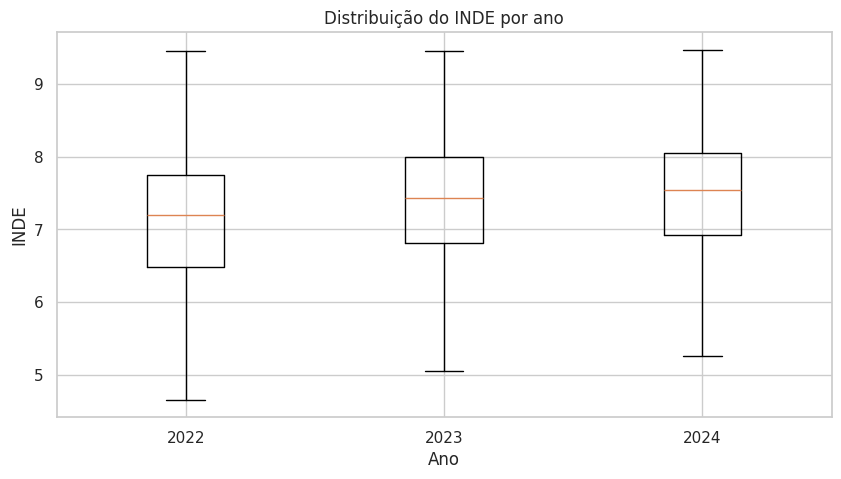

In [ ]:
# 10 — Distribuição do INDE por ano (boxplot)
df_inde = df_long[(df_long["INDICADOR"] == "INDE") & (df_long["VALOR_NUM"].notna())].copy()

if len(df_inde) > 0:
    anos = sorted(df_inde["ANO"].unique())
    dados = [df_inde[df_inde["ANO"] == a]["VALOR_NUM"].values for a in anos]

    plt.figure(figsize=(10, 5))
    plt.boxplot(dados, tick_labels=anos, showfliers=False)
    plt.title("Distribuição do INDE por ano")
    plt.xlabel("Ano")
    plt.ylabel("INDE")
    plt.show()
else:
    print("⚠️ Não há dados de INDE no df_long.")


In [ ]:
# 11 — PEDRA (colunas PEDRA_XX) em formato LONG e análises
pedra_cols = [c for c in df_all.columns if c.startswith("PEDRA_")]

df_pedra_long = df_all[dim_cols + pedra_cols].melt(
    id_vars=dim_cols,
    value_vars=pedra_cols,
    var_name="PEDRA_ANO_COL",
    value_name="PEDRA"
)

# extrai o ano (PEDRA_22 -> 2022)
df_pedra_long["ANO_PEDRA"] = pd.to_numeric(
    df_pedra_long["PEDRA_ANO_COL"].str.replace("PEDRA_", "", regex=False),
    errors="coerce"
)

# converte 20->2020 etc.
df_pedra_long["ANO_PEDRA"] = df_pedra_long["ANO_PEDRA"].apply(lambda x: (2000 + x) if pd.notna(x) and x < 100 else x)

df_pedra_long.head()


,RA,ANO,NOME,GENERO,FASE,TURMA,INSTITUICAO_DE_ENSINO,PEDRA_ANO_COL,PEDRA,ANO_PEDRA
0,RA-1,2022,Aluno-1,Menina,7,A,Escola Pública,PEDRA_20,Ametista,2020
1,RA-2,2022,Aluno-2,Menina,7,A,Rede Decisão,PEDRA_20,Ametista,2020
2,RA-3,2022,Aluno-3,Menina,7,A,Rede Decisão,PEDRA_20,Ametista,2020
3,RA-4,2022,Aluno-4,Menino,7,A,Rede Decisão,PEDRA_20,Ametista,2020
4,RA-5,2022,Aluno-5,Menina,7,A,Rede Decisão,PEDRA_20,Ametista,2020


In [ ]:
# 11.5 — Criar df_wide_ano (formato WIDE por aluno x ano)
# A ideia aqui é: cada linha = (RA, ANO) e cada indicador vira uma coluna (INDE, IAN, IAA, ...)

# Pivot dos indicadores numéricos
df_wide_vals = (
    df_long.pivot_table(
        index=[ID_COL, "ANO"],
        columns="INDICADOR",
        values="VALOR_NUM",
        aggfunc="first"  # se tiver duplicidade, pega o primeiro (pode ajustar depois)
    )
    .reset_index()
)

# Dimensões (dados de contexto) por aluno x ano
df_dims = df_all[dim_cols].drop_duplicates(subset=[ID_COL, "ANO"])

# Junta dimensões + indicadores wide
df_wide_ano = df_dims.merge(df_wide_vals, on=[ID_COL, "ANO"], how="left")

df_wide_ano.shape, df_wide_ano.head(5)


((3030, 15),
      RA   ANO     NOME  GENERO FASE TURMA INSTITUICAO_DE_ENSINO  IAA   IAN  IDA  IEG   INDE  IPP  IPS    IPV
 0  RA-1  2022  Aluno-1  Menina    7     A        Escola Pública  8.3   5.0  4.0  4.1  5.783  NaN  5.6  7.278
 1  RA-2  2022  Aluno-2  Menina    7     A          Rede Decisão  8.8  10.0  6.8  5.2  7.055  NaN  6.3  6.778
 2  RA-3  2022  Aluno-3  Menina    7     A          Rede Decisão  0.0  10.0  5.6  7.9  6.591  NaN  5.6  7.556
 3  RA-4  2022  Aluno-4  Menino    7     A          Rede Decisão  8.8  10.0  5.0  4.5  5.951  NaN  5.6  5.278
 4  RA-5  2022  Aluno-5  Menina    7     A          Rede Decisão  7.9  10.0  5.2  8.6  7.427  NaN  5.6  7.389)

In [ ]:
# 12 — Feature engineering simples (ex.: DELTA_INDE ano a ano por aluno)
df_wide_ano = df_wide_ano.sort_values([ID_COL, "ANO"])

if "INDE" in df_wide_ano.columns:
    df_wide_ano["DELTA_INDE"] = df_wide_ano.groupby(ID_COL)["INDE"].diff()
else:
    df_wide_ano["DELTA_INDE"] = np.nan

df_wide_ano[[ID_COL, "ANO", "INDE", "DELTA_INDE"]].head(10)


,RA,ANO,INDE,DELTA_INDE
0,RA-1,2022,5.783000,NaN
1855,RA-1,2023,5.783000,0.000000
2958,RA-1,2024,5.783133,0.000133
9,RA-10,2022,5.784000,NaN
99,RA-100,2022,7.618000,NaN
1072,RA-1000,2023,7.916200,NaN
2225,RA-1000,2024,7.916200,0.000000
1074,RA-1001,2023,8.116200,NaN
2227,RA-1001,2024,8.116200,0.000000
1075,RA-1002,2023,7.901200,NaN


In [ ]:
# 13 — Exportar “data mart” para Power BI (recomendado)
OUT_WIDE = "datamart_wide_aluno_ano.csv"
OUT_LONG = "datamart_long_indicadores.csv"

df_wide_ano.to_csv(OUT_WIDE, index=False, encoding="utf-8")
df_long.to_csv(OUT_LONG, index=False, encoding="utf-8")

print("✅ Exportado:", OUT_WIDE)
print("✅ Exportado:", OUT_LONG)


✅ Exportado: datamart_wide_aluno_ano.csv
✅ Exportado: datamart_long_indicadores.csv


In [ ]:
df_wide_ano.head()

,RA,ANO,NOME,GENERO,FASE,TURMA,INSTITUICAO_DE_ENSINO,IAA,IAN,IDA,IEG,INDE,IPP,IPS,IPV,DELTA_INDE
0,RA-1,2022,Aluno-1,Menina,7,A,Escola Pública,8.3,5.0,4.0,4.1,5.783000,NaN,5.6,7.278,NaN
1855,RA-1,2023,NaN,Feminino,FASE 8,8E,Privada *Parcerias com Bolsa 100%,NaN,10.0,NaN,NaN,5.783000,NaN,NaN,NaN,0.000000
2958,RA-1,2024,NaN,Feminino,8E,8E,Privada *Parcerias com Bolsa 100%,NaN,10.0,NaN,0.0,5.783133,NaN,NaN,NaN,0.000133
9,RA-10,2022,Aluno-10,Menina,7,A,Escola Pública,8.3,5.0,4.1,5.2,5.784000,NaN,5.0,7.056,NaN
99,RA-100,2022,Aluno-100,Menina,4,A,Rede Decisão,8.8,10.0,7.6,7.8,7.618000,NaN,5.0,7.250,NaN


In [ ]:
df_long.head()

,RA,ANO,NOME,GENERO,FASE,TURMA,INSTITUICAO_DE_ENSINO,INDICADOR,VALOR_NUM
0,RA-1,2022,Aluno-1,Menina,7,A,Escola Pública,INDE,5.783
1,RA-2,2022,Aluno-2,Menina,7,A,Rede Decisão,INDE,7.055
2,RA-3,2022,Aluno-3,Menina,7,A,Rede Decisão,INDE,6.591
3,RA-4,2022,Aluno-4,Menino,7,A,Rede Decisão,INDE,5.951
4,RA-5,2022,Aluno-5,Menina,7,A,Rede Decisão,INDE,7.427


In [ ]:
#Verificar duplicidade
dup = df_wide_ano.duplicated(subset=[ID_COL, "ANO"]).sum()
print("Duplicados (RA, ANO):", dup)

if dup > 0:
    display(df_wide_ano[df_wide_ano.duplicated(subset=[ID_COL, "ANO"], keep=False)]
            .sort_values([ID_COL, "ANO"]).head(20))


Duplicados (RA, ANO): 0


In [ ]:
# Analise por ano
indicadores_num = ["INDE","IAA","IAN","IDA","IEG","IPP","IPS","IPV"]
cols_exist = [c for c in indicadores_num if c in df_wide_ano.columns]

cobertura = (df_wide_ano
             .groupby("ANO")[cols_exist]
             .apply(lambda x: x.notna().mean())
            )
display(cobertura)


,INDE,IAA,IAN,IDA,IEG,IPP,IPS,IPV
ANO,,,,,,,,
2022,1.000000,1.000000,1.0,1.000000,1.000000,0.000000,1.000000,1.000000
2023,0.947732,0.937870,1.0,0.924063,0.925049,0.925049,0.931953,0.925049
2024,0.937716,0.911765,1.0,0.912630,1.000000,0.911765,0.911765,0.911765


In [ ]:
# Verificação de nulos
dims_check = ["NOME","GENERO","FASE","TURMA","INSTITUICAO_DE_ENSINO"]
dims_exist = [c for c in dims_check if c in df_wide_ano.columns]

nulos_dims = df_wide_ano[dims_exist].isna().mean().sort_values(ascending=False)
display(nulos_dims)


,0
NOME,0.716172
INSTITUICAO_DE_ENSINO,0.000330
GENERO,0.000000
FASE,0.000000
TURMA,0.000000


In [ ]:
#Analise dos deltas
df_delta = df_wide_ano.dropna(subset=["INDE"]).copy()
display(df_delta["DELTA_INDE"].describe())

# top maiores variações (só pra sanity check)
display(df_delta.sort_values("DELTA_INDE", ascending=False)[[ID_COL,"ANO","INDE","DELTA_INDE"]].head(10))
display(df_delta.sort_values("DELTA_INDE", ascending=True)[[ID_COL,"ANO","INDE","DELTA_INDE"]].head(10))


,DELTA_INDE
count,1319.000000
mean,-0.000006
std,0.000170
min,-0.000499
25%,0.000000
50%,0.000000
75%,0.000000
max,0.000498


,RA,ANO,INDE,DELTA_INDE
2701,RA-384,2024,7.558498,0.000498
2132,RA-854,2024,8.098496,0.000496
2342,RA-827,2024,7.412495,0.000495
2695,RA-236,2024,7.110494,0.000494
2974,RA-88,2024,7.498493,0.000493
1953,RA-858,2024,7.523492,0.000492
2557,RA-469,2024,7.624483,0.000483
2453,RA-490,2024,7.576481,0.000481
2525,RA-389,2024,7.184480,0.000480
2568,RA-464,2024,6.745480,0.000480


,RA,ANO,INDE,DELTA_INDE
2779,RA-115,2024,5.885501,-0.000499
2536,RA-365,2024,8.062503,-0.000497
2636,RA-586,2024,7.987503,-0.000497
2609,RA-632,2024,6.995504,-0.000496
2899,RA-78,2024,7.039505,-0.000495
2100,RA-684,2024,8.259505,-0.000495
2570,RA-466,2024,6.825507,-0.000493
2321,RA-737,2024,8.057508,-0.000492
2798,RA-197,2024,8.217508,-0.000492
2172,RA-747,2024,7.675509,-0.000491


In [ ]:
id_col = "RA"
dup = df_wide_ano.duplicated(subset=[id_col, "ANO"]).sum()
print("Duplicados (RA, ANO):", dup)

# se tiver duplicados, mostrar alguns
if dup > 0:
    display(
        df_wide_ano[df_wide_ano.duplicated(subset=[id_col, "ANO"], keep=False)]
        .sort_values([id_col, "ANO"])
        .head(30)
    )


Duplicados (RA, ANO): 0


In [ ]:
tmp = (
    df_wide_ano
    .dropna(subset=["INDE"])
    .groupby("RA")["ANO"]
    .nunique()
    .rename("qtd_anos_com_inde")
    .reset_index()
)

print("RAs com INDE em mais de 1 ano:", (tmp["qtd_anos_com_inde"] > 1).sum())

# pega alguns RAs e vê a evolução
amostra_ra = (
    df_wide_ano.dropna(subset=["INDE"])
    .groupby("RA")["ANO"].nunique()
    .sort_values(ascending=False)
    .head(5)
    .index
)

display(df_wide_ano[df_wide_ano["RA"].isin(amostra_ra)][["RA","ANO","INDE","DELTA_INDE"]]
        .sort_values(["RA","ANO"]))


RAs com INDE em mais de 1 ano: 851


,RA,ANO,INDE,DELTA_INDE
89,RA-90,2022,9.442000,NaN
1726,RA-90,2023,9.442000,0.000000
2904,RA-90,2024,9.441522,-0.000478
91,RA-92,2022,6.957000,NaN
1779,RA-92,2023,6.957000,0.000000
2894,RA-92,2024,6.957316,0.000316
92,RA-93,2022,8.941000,NaN
1802,RA-93,2023,8.941000,0.000000
2910,RA-93,2024,8.940600,-0.000400
93,RA-94,2022,8.921000,NaN
